# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Objetivos

1. Descargar y preparar los datos.
2. Remuestrear la serie temporal a intervalos de una hora.
3. Analizar la tendencia y la estacionalidad.
4. Crear características temporales, rezagos y medias móviles.
5. Separar los datos respetando el orden temporal y reservar el 10% para la prueba final.
6. Entrenar diferentes modelos y probar hiperparámetros.
7. Seleccionar el mejor modelo utilizando el conjunto de validación.
8. Reentrenar el modelo seleccionado con entrenamiento + validación y evaluarlo una sola vez sobre el conjunto de prueba.

### Datos

Los datos se almacenan en `/datasets/taxi.csv` y el número de pedidos se encuentra en la columna `num_orders`.


# Preparación de los datos

En esta etapa se carga el conjunto de datos, se convierte la columna temporal en índice y se remuestrea la serie para que cada observación represente una hora.

## Flujo de preparación

```text
Datos originales (10 min)
        ↓
Índice datetime + orden cronológico
        ↓
Remuestreo a 1 hora
        ↓
Serie horaria de pedidos
        ↓
Análisis exploratorio
```


In [2]:
import warnings

import sys
import os
# Le dice python que busque liberrías ahí también
sys.path.append(os.path.join('../src'))
import funciones_personales as fp

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor


In [3]:
# importa el dataset ya como serie de tiempo
df=pd.read_csv('../data/taxi.csv', index_col=[0], parse_dates=[0])

# resample por hora
df.sort_index(inplace=True)
df= df.resample('1H').sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


/tmp/ipykernel_5849/290890023.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df= df.resample('1H').sum()


### Características del conjunto de datos

- Periodo analizado: **1 de marzo al 31 de agosto de 2018**.
- Datos originales registrados cada **10 minutos**.
- Después del remuestreo, cada observación representa una hora de demanda.

El remuestreo es necesario porque el objetivo del proyecto es predecir la cantidad de pedidos para la **próxima hora**.

<AxesSubplot:xlabel='datetime'>

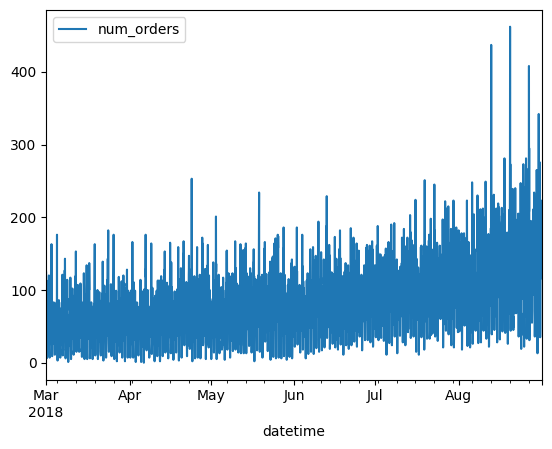

In [3]:
df.plot()

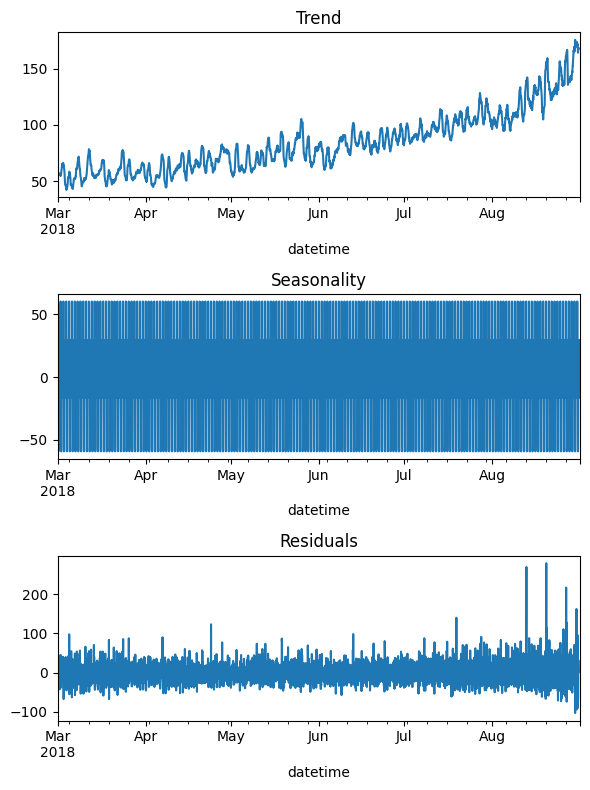

In [4]:
fp.descomponer_plots(df)

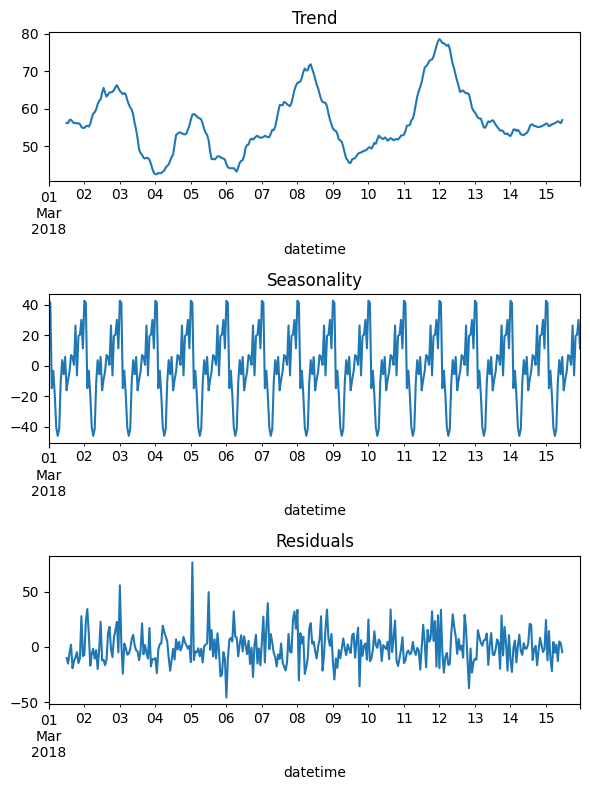

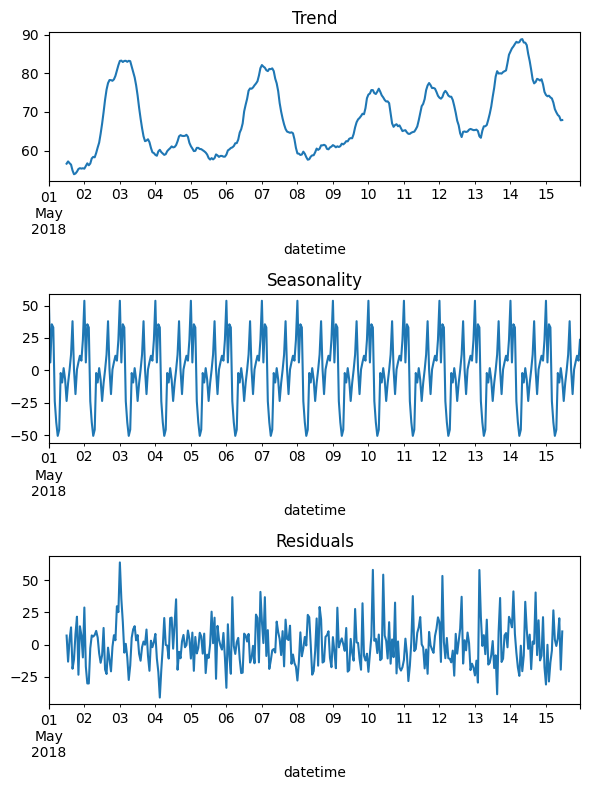

In [5]:
fp.descomponer_plots(df,
                    date_inicio='2018-03-01',
                    date_final='2018-03-15')
fp.descomponer_plots(df,
                    date_inicio='2018-05-01',
                    date_final='2018-05-15')


## Conclusiones del análisis de la serie temporal

- La serie presenta una **tendencia general creciente** durante el período analizado.
- Se observa una **estacionalidad diaria clara** en el número de pedidos.
- Durante el día aparecen varios picos de demanda, siendo el de las últimas horas del día el más pronunciado.
- La tendencia presenta variaciones a lo largo de los meses: en marzo es relativamente estable, mientras que en mayo se observa una evolución más positiva.
- Los residuos presentan variaciones puntuales, pero no muestran una estructura tan marcada como la componente estacional.
- La estacionalidad horaria y la dependencia de los valores recientes justifican el uso de **variables temporales, rezagos (`lag`) y medias móviles (`rolling_mean`)**.

### Implicación para el modelado

La información histórica inmediata es especialmente relevante para predecir la demanda de la siguiente hora. Por ello, la ingeniería de características se centrará en capturar tanto el comportamiento de las últimas horas como los patrones diarios.

# Flujo general del proyecto

```text
Preparación → Análisis → División temporal → Features
                                      ↓
                         Modelos + hiperparámetros
                                      ↓
                             Validación (10%)
                                      ↓
                         Selección del mejor modelo
                                      ↓
                         Reentrenamiento (90%)
                                      ↓
                          Prueba final (10%)
                                      ↓
                         Conclusión y evaluación
```

**Regla clave:** el conjunto de prueba se mantiene apartado hasta la evaluación final.

## Separación de datos

La separación se realiza **sin mezclar el orden temporal**, ya que en una serie temporal no debemos utilizar observaciones futuras para entrenar un modelo que hará predicciones sobre el futuro.

El 10% final de los datos se reserva exclusivamente para la evaluación final. El 90% restante se divide en entrenamiento y validación.

### Pipeline de división temporal

```text
100% de los datos
│
├── 80% TRAIN ──────────────→ entrenamiento de modelos
│                              │
│                              ↓
├── 10% VALID ───────────────→ selección de features e hiperparámetros
│                              │
│                              ↓
└── 10% TEST ────────────────→ evaluación final (solo una vez)
```

El conjunto de prueba permanece apartado durante toda la selección del modelo.

In [6]:
train_valid, test = train_test_split(
    df,
    shuffle=False,
    test_size=0.1
)

train, valid = train_test_split(
    train_valid,
    shuffle=False,
    test_size=1/9
)

In [7]:
# creación de datasets de entrenamiento y prueba
train_features= train.dropna().drop('num_orders', axis=1)
train_target= train.dropna()['num_orders']
valid_features= valid.drop('num_orders', axis=1)
valid_target= valid['num_orders']

# Ingeniería de características

Para predecir el número de pedidos de la próxima hora se incorporaron características temporales y variables basadas en valores históricos de la serie.

Se utilizaron:

- `year`, `month`, `day`, `dayofweek` y `hour` para representar la posición temporal de cada observación.
- Variables `lag` para incorporar información de horas anteriores.
- `rolling_mean` para representar el nivel promedio reciente de la demanda.

Se probaron diferentes cantidades de rezagos y tamaños de ventana. El objetivo fue determinar qué combinación captura mejor la dinámica reciente de la demanda sin utilizar información futura.

## Pipeline de features

```text
Serie horaria
     ↓
Variables calendario
(year, month, day, dayofweek, hour)
     ↓
Rezagos históricos
(lag_1 ... lag_n)
     ↓
Media móvil desplazada
(rolling_mean)
     ↓
Eliminar NaN iniciales
     ↓
Matriz de características para ML
```


In [9]:
'''
lista_features = [
    {'max_lag': 24, 'rolling_mean_size': 4},
    {'max_lag': 48, 'rolling_mean_size': 4},
    {'max_lag': 48, 'rolling_mean_size': 8},
    {'max_lag': 48, 'rolling_mean_size': 48},
    {'max_lag': 48, 'rolling_mean_size': 72},
]
'''
# Crea las listas de números que se le les darpa a lag y rolling
lags_values=[4,8,24,72]
rolling_values={4,8,24,72}

lista_features = [
    {'max_lag': i[0], 
     'rolling_mean_size': i[1]}
    for i in itertools.product(lags_values, rolling_values)
]

resultado_lr, mejor_modelo_lr = fp.probar_hiperparametros(
    modelo_base=LinearRegression,
    lista_parametros=[{}],
    X_train=train_features,
    y_train=train_target,
    X_valid=valid_features,
    y_valid=valid_target,
    nombre_modelo='Regresión lineal',
    column_name='num_orders',
    lista_features=lista_features
)

resultado_lr

,Modelo,Parámetros,RMSE,Tiempo entrenamiento (s),Tiempo predicción (s),max_lag,rolling_mean_size
0,Regresión lineal,,30.717727,0.009297,0.002232,72,4
1,Regresión lineal,,30.718490,0.008479,0.002313,72,24
2,Regresión lineal,,30.719731,0.008453,0.002220,72,8
3,Regresión lineal,,30.722412,0.008205,0.002304,72,72
4,Regresión lineal,,34.154522,0.003214,0.001764,24,24
5,Regresión lineal,,34.154522,0.003446,0.001776,24,4
6,Regresión lineal,,34.154522,0.003831,0.042179,24,8
7,Regresión lineal,,34.195090,0.003251,0.001713,24,72
8,Regresión lineal,,40.357188,0.001768,0.001179,8,72
9,Regresión lineal,,40.395330,0.001828,0.001138,8,24


### Conclusión: Regresión Lineal

Se evaluaron diferentes combinaciones de rezagos y tamaño de ventana. La mejor configuración de la **Regresión Lineal** fue utilizar **72 rezagos** y una **media móvil de 4 horas**, obteniendo una RECM de **30.72** en el conjunto de validación.

Este resultado está claramente por debajo del límite de **48** establecido por el proyecto. Aun así, se evaluaron modelos no lineales para comprobar si era posible mejorar el desempeño.


In [23]:
# elige los mejores caracteristicas temporales
lista_features_rf=[
    {
        'max_lag':72, 'rolling_mean_size':4
    }
]
# Elige las diferentes combinaciones de hiperparámetros
lista_parametros_rf = [
    {
        'n_estimators': 400,
        'max_depth': 10,
        'min_samples_leaf': 1,
        'random_state': 42
    },
    {
        'n_estimators': 400,
        'max_depth': 15,
        'min_samples_leaf': 1,
        'random_state': 42
    },
    {
        'n_estimators': 400,
        'max_depth': 20,
        'min_samples_leaf': 1,
        'random_state': 42
    },
    {
        'n_estimators': 200,
        'max_depth': 15,
        'min_samples_leaf': 2,
        'random_state': 42
    },
    {
        'n_estimators': 200,
        'max_depth': 20,
        'min_samples_leaf': 2,
        'random_state': 42
    }
]


resultado_rf, mejor_modelo_rf = fp.probar_hiperparametros(
    modelo_base=RandomForestRegressor,
    lista_parametros=lista_parametros_rf,
    X_train=train_features,
    y_train=train_target,
    X_valid=valid_features,
    y_valid=valid_target,
    nombre_modelo='Random Forest',
    column_name='num_orders',
    lista_features=lista_features_rf)

resultado_rf


,Modelo,Parámetros,RMSE,Tiempo entrenamiento (s),Tiempo predicción (s),max_lag,rolling_mean_size
0,Random Forest,"n_estimators=400, max_depth=20, min_samples_le...",31.037340,38.386095,0.035717,72,4
1,Random Forest,"n_estimators=400, max_depth=15, min_samples_le...",31.077147,36.528883,0.032722,72,4
2,Random Forest,"n_estimators=400, max_depth=10, min_samples_le...",31.373951,29.071936,0.023802,72,4


In [ ]:
# Comparación de los mejores resultados obtenidos hasta este punto
comparacion_modelos = pd.concat([
    resultado_lr.head(1),
    resultado_rf.head(1)
], ignore_index=True)

comparacion_modelos[['Modelo', 'RMSE', 'Tiempo entrenamiento (s)', 'Tiempo predicción (s)',
                     'max_lag', 'rolling_mean_size']]

In [29]:
# elige los valores de hiperparametros
lista_parametros_mejor_rf= [
    {
        'n_estimators': 200,
        'max_depth': 20,
        'min_samples_leaf': 1,
        'random_state': 42
    }
]

# elige combinaciones de características temporales
lista_features_mejor_rf = [
    {'max_lag': 48, 'rolling_mean_size': 4},
    {'max_lag': 48, 'rolling_mean_size': 8},
    {'max_lag': 48, 'rolling_mean_size': 24},
    {'max_lag': 24, 'rolling_mean_size': 4},
    {'max_lag': 24, 'rolling_mean_size': 8},
]

resultado_mejor_rf, mejor_modelo_mejor_rf = fp.probar_hiperparametros(
    modelo_base=RandomForestRegressor,
    lista_parametros=lista_parametros_mejor_rf,
    X_train=train_features,
    y_train=train_target,
    X_valid=valid_features,
    y_valid=valid_target,
    nombre_modelo='Random Forest',
    column_name='num_orders',
    lista_features=lista_features_mejor_rf)



In [30]:
resultado_mejor_rf

,Modelo,Parámetros,RMSE,Tiempo entrenamiento (s),Tiempo predicción (s),max_lag,rolling_mean_size
0,Random Forest,"n_estimators=200, max_depth=20, min_samples_le...",31.916491,7.618811,0.017108,24,8
1,Random Forest,"n_estimators=200, max_depth=20, min_samples_le...",31.954326,13.603478,0.017479,48,8
2,Random Forest,"n_estimators=200, max_depth=20, min_samples_le...",31.960682,13.474420,0.018321,48,4
3,Random Forest,"n_estimators=200, max_depth=20, min_samples_le...",32.231857,13.529653,0.017937,48,24
4,Random Forest,"n_estimators=200, max_depth=20, min_samples_le...",32.433242,7.580312,0.017850,24,4


### Conclusión: Random Forest

Al utilizar los mejores valores de rezago y tamaño de ventana, y variar la cantidad de árboles y la profundidad máxima, se obtuvo una RECM aproximada de **31.04**.

Este resultado es ligeramente superior al obtenido por la Regresión Lineal (**30.72**) y requirió un tiempo de entrenamiento considerablemente mayor.

Posteriormente, al fijar el modelo en **200 árboles y una profundidad máxima de 20**, y variar los rezagos y el tamaño de la ventana, el desempeño empeoró.

Por lo tanto, **Random Forest no supera a la Regresión Lineal** en el conjunto de validación y no se selecciona como modelo final.

A continuación, se evaluará LightGBM para comprobar si es posible obtener una mejora adicional.


In [31]:
# características temporales
lista_features_lgbm = [
    {'max_lag': 72, 'rolling_mean_size': 4}
]
# hiperparámetros
lista_parametros_lgbm = [
    {
        'n_estimators': 200,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'max_depth': -1,
        'random_state': 42,
        'verbosity': -1
    },
    {
        'n_estimators': 400,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'max_depth': -1,
        'random_state': 42,
        'verbosity': -1
    },
    {
        'n_estimators': 600,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'max_depth': -1,
        'random_state': 42,
        'verbosity': -1
    },

    {
        'n_estimators': 400,
        'learning_rate': 0.05,
        'num_leaves': 15,
        'max_depth': -1,
        'random_state': 42,
        'verbosity': -1
    },
    {
        'n_estimators': 400,
        'learning_rate': 0.05,
        'num_leaves': 63,
        'max_depth': -1,
        'random_state': 42,
        'verbosity': -1
    },

    {
        'n_estimators': 400,
        'learning_rate': 0.03,
        'num_leaves': 31,
        'max_depth': -1,
        'random_state': 42,
        'verbosity': -1
    },
    {
        'n_estimators': 600,
        'learning_rate': 0.03,
        'num_leaves': 31,
        'max_depth': -1,
        'random_state': 42,
        'verbosity': -1
    },

    {
        'n_estimators': 400,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'max_depth': 10,
        'random_state': 42,
        'verbosity': -1
    },
    {
        'n_estimators': 400,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'max_depth': 15,
        'random_state': 42,
        'verbosity': -1
    }
]

resultado_lgbm, mejor_modelo_lgbm = fp.probar_hiperparametros(
    modelo_base=LGBMRegressor,
    lista_parametros=lista_parametros_lgbm,
    X_train=train_features,
    y_train=train_target,
    X_valid=valid_features,
    y_valid=valid_target,
    nombre_modelo='LightGBM',
    column_name='num_orders',
    lista_features=lista_features_lgbm
)

In [18]:

resultado_lgbm

,Modelo,Parámetros,RMSE,Tiempo entrenamiento (s),Tiempo predicción (s),max_lag,rolling_mean_size
0,LightGBM,"n_estimators=400, learning_rate=0.05, num_leav...",48.030413,4.322900,0.078831,72,4
1,LightGBM,"n_estimators=600, learning_rate=0.05, num_leav...",48.716756,3.501579,0.004849,72,4
2,LightGBM,"n_estimators=400, learning_rate=0.05, num_leav...",48.804788,2.612758,0.080896,72,4
3,LightGBM,"n_estimators=400, learning_rate=0.05, num_leav...",48.892512,2.508103,0.004063,72,4
4,LightGBM,"n_estimators=400, learning_rate=0.05, num_leav...",48.900532,1.306991,0.003504,72,4
5,LightGBM,"n_estimators=400, learning_rate=0.05, num_leav...",48.925293,2.170988,0.004217,72,4
6,LightGBM,"n_estimators=200, learning_rate=0.05, num_leav...",48.936653,1.220945,0.003930,72,4
7,LightGBM,"n_estimators=400, learning_rate=0.03, num_leav...",49.387484,2.601342,0.004101,72,4
8,LightGBM,"n_estimators=600, learning_rate=0.03, num_leav...",49.677170,3.700771,0.004869,72,4


### Conclusión: LightGBM

LightGBM obtuvo el peor desempeño entre los modelos evaluados. La configuración evaluada con **72 rezagos y una media móvil de 4 horas** obtuvo una RECM de aproximadamente **48.03** en validación.

Este resultado es muy superior al de la Regresión Lineal (**30.72**) y al de Random Forest (**31.04**). Por lo tanto, **LightGBM no ofrece una mejora sobre los modelos anteriores y no se selecciona para el modelo final**.

## 4. Elección del modelo final

La comparación de los modelos en el conjunto de validación muestra que la **Regresión Lineal** obtuvo el menor error.

| Modelo | RECM en validación | Resultado |
|---|---:|---|
| **Regresión Lineal** | **30.72** | Mejor resultado |
| Random Forest | 31.04 | No mejora a Regresión Lineal |
| LightGBM | 48.03 | Desempeño inferior |

### Configuración seleccionada

- **Modelo:** Regresión Lineal
- **Rezagos:** 72
- **Media móvil:** 4 horas
- **RECM en validación:** 30.72

La selección se realiza exclusivamente con los conjuntos de entrenamiento y validación. El conjunto de prueba todavía no se ha utilizado para tomar decisiones sobre el modelo.

In [37]:
print(mejor_modelo_lr)


LinearRegression()


## 5. Formación del modelo final

Una vez seleccionada la configuración, se reentrena un nuevo modelo utilizando conjuntamente los datos de **train + valid**. De esta manera se aprovecha el 90% disponible antes de realizar la evaluación final.

La configuración de características se mantiene fija en **72 rezagos y una media móvil de 4 horas**, ya que fue seleccionada durante la etapa de validación.

### Pipeline de formación final

```text
TRAIN + VALID (90%)
        ↓
Crear features: 72 lags + rolling 4 h
        ↓
Eliminar NaN iniciales
        ↓
Entrenar Regresión Lineal
        ↓
Modelo final
```

El conjunto `test` permanece completamente separado durante este proceso.


## 6. Prueba final

El modelo final se evalúa una sola vez sobre el **10% reservado para prueba**. Para generar los primeros rezagos del conjunto de prueba se utiliza como contexto el final de `train + valid`, sin utilizar valores futuros del propio conjunto de prueba.

### Pipeline de evaluación final

```text
Final de TRAIN + VALID
        ↓
Contexto de 72 observaciones
        ↓
TEST (10%)
        ↓
Crear features con 72 lags + rolling 4 h
        ↓
Predicciones del modelo final
        ↓
RECM final
```

In [10]:
# junta el 90% de datos originales
train_valid = pd.concat([train, valid])

# Define y aplica lascaracterísticas temporales a train
max_lag = 72
rolling_size = 4

train_valid_features = fp.make_features(
    train_valid.copy(),
    'num_orders',
    max_lag,
    rolling_size
)

train_valid_features = train_valid_features.dropna()

X_train_final = train_valid_features.drop(columns=['num_orders'])
y_train_final = train_valid_features['num_orders']

#obtiene los datos anteriores (que qeudarían como nan) de los datos de entrenamiento
contexto = train_valid[['num_orders']].iloc[-max_lag:].copy()

test_con_contexto = pd.concat([
    contexto,
    test[['num_orders']]
])

#Construye las características tenporales
test_features_final = fp.make_features(
    test_con_contexto,
    'num_orders',
    max_lag,
    rolling_size
)

test_features_final = test_features_final.iloc[max_lag:]
X_test_final = test_features_final.drop(columns=['num_orders'])
y_test_final = test_features_final['num_orders']



In [11]:
modelo_final_lr = LinearRegression()

modelo_final_lr.fit(
    X_train_final,
    y_train_final
)
pred_test = modelo_final_lr.predict(X_test_final)

rmse_test = mean_squared_error(
    y_test_final,
    pred_test,
    squared=False
)

print(f"RECM final en test: {rmse_test:.2f}")

RECM final en test: 42.48


## 7. Conclusión final

Se analizaron los datos históricos de pedidos de taxis y se remuestrearon en intervalos de una hora. El análisis mostró una tendencia general creciente y una estacionalidad diaria clara, por lo que se incorporaron variables temporales, rezagos y medias móviles para representar la dinámica de la demanda.

Se evaluaron **Regresión Lineal, Random Forest y LightGBM**, utilizando diferentes configuraciones de hiperparámetros y combinaciones de características temporales.

La **Regresión Lineal**, con **72 rezagos y una media móvil de 4 horas**, obtuvo el mejor resultado en validación, con una RECM de **30.72**. Random Forest obtuvo **31.04**, mientras que LightGBM obtuvo **48.03**.

Después de seleccionar el modelo con el conjunto de validación, se reentrenó una nueva Regresión Lineal utilizando **train + valid (90%)**. Finalmente, se evaluó una sola vez sobre el **10% reservado para prueba**, obteniendo una **RECM final de 42.48**.

El resultado final cumple el requisito del proyecto de obtener una RECM **no superior a 48**. Por lo tanto, la solución desarrollada cumple con el objetivo de predecir la cantidad de pedidos de taxis para la próxima hora.
